In [ ]:
from utilities import getQueryData
from datetime import datetime, timedelta
import mysql.connector
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import shap as sp


c:\Users\assetplan\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
###############################
# Conexión a la base de datos #
###############################

# Set up the connection parameters
host = 'dp-prod-bi.cluster-ro-czb4wih3oe0v.us-east-1.rds.amazonaws.com'
database = 'bi_assetplan'
username = 'bruno.cheleon'
password = 'hGykHG6v*4@JNuVyfkwG-uwY'

conn = mysql.connector.connect(
    host=host,
    user=username,
    password=password,
    database=database
)

cursor = conn.cursor()

In [3]:
#####################
# Lectura de tablas #
#####################

# Lectura de DimProperties
queryDimProperties = "SELECT property_id, unit_id, created, acepta_mascotas, unit_type, mf, m2_terraza, m2_utiles, edificio, sector_provincia, nombre_tipologia, first_time_rented, first_time_rp, actual_activa, ha_sido_arrendada, owner_id FROM bi_DimProperties"
table_dimProperties = getQueryData(queryDimProperties, cursor)
print("DimProperties Leido..")

DimProperties Leido..


In [4]:
# # Lectura de FactProperties
# queryFactProperties = "SELECT property_id, year_month_day, churn_unit_id_no_rented FROM bi_FactProperties WHERE churn_unit_id_no_rented = 1"
# table_factProperties = getQueryData(queryFactProperties, cursor)
# print("FactProperties Leido..")


In [5]:
# Lectura de FactProperties
queryFactProperties = "SELECT property_id, nombre_estado_vacios, year_month_day, churn_unit_id_no_rented FROM bi_FactProperties where created >= '2024-01-01'"
table_factProperties = getQueryData(queryFactProperties, cursor)
print("FactProperties Leido..")

FactProperties Leido..


In [6]:
# Lectura de FactPricing
queryFactPricing = "SELECT * FROM bi_FactPricing"
table_factPricing = getQueryData(queryFactPricing, cursor)
table_factPricing["monto_depto"] = table_factPricing["monto_depto"].astype('Float64')
print("FactPricing Leido..")

FactPricing Leido..


In [7]:
# Lectura de DimPIViews
queryDimPIViews = "SELECT * FROM bi_DimPIViews"
table_dimPIViews = getQueryData(queryDimPIViews, cursor)
print("DimPIViews Leido..")

DimPIViews Leido..


In [8]:
# Lectura de DimSchedules
queryDimSchedules = "SELECT * FROM bi_DimSchedules WHERE schedule_type_id = 2"
table_dimSchedules = getQueryData(queryDimSchedules, cursor)
table_dimSchedules = table_dimSchedules.sort_values(by = ["property_id", "schedule_date"])
table_dimSchedules = table_dimSchedules.drop_duplicates(subset = "property_id", keep = "first")
table_dimSchedules = table_dimSchedules[["property_id", "schedule_date"]]
print("DimSchedules Leido..")

DimSchedules Leido..


In [9]:
# Lectura de DimContratos
queryDimContratos = "SELECT * FROM bi_DimContratos"
table_dimcontratos = getQueryData(queryDimContratos, cursor)
print("table_dimcontratos Leido..")

table_dimcontratos Leido..


In [10]:
def RandomForest_Classifier(X,y, params = {'n_estimators': 500, 'max_leaf_nodes': 16, 'n_jobs': -1}):

    # Modeling
    #rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1) # class_weight={0: 1, 1: 12}
    rnd_clf = RandomForestClassifier(**params) # class_weight={0: 1, 1: 12}
    rnd_clf.fit(X, y)

    # Cross Validation Score
    crossValScore = cross_val_score(rnd_clf, X, y, cv=3, scoring="accuracy")

    # Confusion Matrix
    y_pred = cross_val_predict(rnd_clf, X, y, cv=3)
    confusionMatrix = confusion_matrix(y, y_pred)
    
    #Precision Score
    precisionScore = precision_score(y, y_pred)

    #Recall Score
    recallScore = recall_score(y, y_pred)

    # F1 Score
    F1Score = f1_score(y, y_pred)
    
    # AUC Score
    y_scores = cross_val_predict(rnd_clf, X, y, cv=3, method="predict_proba")
    y_scores  = y_scores[:,1]
    AUCScore = roc_auc_score(y, y_scores)

    print("Cross Validation Score:\n", crossValScore, end = '\n\n')
    print("Confusion Matrix:\n", confusionMatrix, end = '\n\n')
    print("Precision Score:\n", precisionScore, end = '\n\n')
    print("Recall Score:\n", recallScore, end = '\n\n')
    print("F1 Score:\n", F1Score, end = '\n\n')
    print("AUC Score:\n", AUCScore, end = '\n\n')

    return rnd_clf, crossValScore, confusionMatrix, precisionScore, recallScore, F1Score, AUCScore

In [11]:
####################
# Data Engineering #
####################

#Unidades churneadas y no rentadas
lista_unidades_churn_no_rented= table_factProperties[table_factProperties["churn_unit_id_no_rented"] == 1]

lista_unidades_churn_no_rented= lista_unidades_churn_no_rented.merge(table_dimProperties[["property_id", "created", "first_time_rented", "ha_sido_arrendada"]], on= "property_id", how="left")
lista_unidades_churn_no_rented=lista_unidades_churn_no_rented[lista_unidades_churn_no_rented["ha_sido_arrendada"]== "No"]
lista_unidades_churn_no_rented= lista_unidades_churn_no_rented[lista_unidades_churn_no_rented["first_time_rented"].isna()]

lista_unidades_churn_no_rented['year_month_day'] = pd.to_datetime(lista_unidades_churn_no_rented['year_month_day'])
lista_unidades_churn_no_rented['created'] = pd.to_datetime(lista_unidades_churn_no_rented['created'])
diferencia = lista_unidades_churn_no_rented['year_month_day'] - lista_unidades_churn_no_rented['created']
lista_unidades_churn_no_rented = lista_unidades_churn_no_rented[diferencia <= pd.Timedelta(days=90)].copy()

lista_churn_no_rented = lista_unidades_churn_no_rented['property_id'].tolist()

lista_unidades_churn_no_rented




,property_id,nombre_estado_vacios,year_month_day,churn_unit_id_no_rented,created,first_time_rented,ha_sido_arrendada
80,499225,Sin administración,2025-02-10,1,2024-11-15,NaT,No
86,500247,Sin administración,2025-02-12,1,2024-11-20,NaT,No
101,500341,Sin administración,2025-02-06,1,2024-11-22,NaT,No
102,500348,Sin administración,2025-02-19,1,2024-11-22,NaT,No
108,500829,Sin administración,2025-02-06,1,2024-11-27,NaT,No
...,...,...,...,...,...,...,...
1459,530494,Inicio de servicio,2026-04-09,1,2026-04-06,NaT,No
1460,530499,Inicio de servicio,2026-04-08,1,2026-04-06,NaT,No
1461,530558,Inicio de servicio,2026-04-09,1,2026-04-07,NaT,No
1462,530571,Sin administración,2026-04-08,1,2026-04-07,NaT,No


In [12]:
base= table_dimProperties
# Filtros sobre las unidades que queremos entrenar
base = base[base["unit_type"] == "Appartment"]
base = base[base["mf"] == 0]
base = base[base["sector_provincia"].isin(['Santiago - Centro', 'Santiago - Surponiente', 'Santiago - Nororiente', 'Santiago - Sur', 'Santiago - Suroriente', 'Santiago - Norte', 'Santiago - Norponiente'])]
base = base[base["created"] >= pd.to_datetime("2024-01-01")]

base

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_terraza,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id
64922,473252,837_317_3,2024-01-02,1,Appartment,0,2.00,30.00,Lo Vial,Santiago - Sur,1D1B,NaT,NaT,1,No,9498
64924,473259,2585_707_3,2024-01-02,1,Appartment,0,6.00,31.00,Edificio Santo,Santiago - Centro,1D1B,NaT,2024-01-05,0,No,9499
64925,473260,2585_812_3,2024-01-02,1,Appartment,0,2.00,31.00,Edificio Santo,Santiago - Centro,1D1B,NaT,2024-01-05,0,No,9499
64926,473261,2585_811_3,2024-01-02,1,Appartment,0,2.00,31.00,Edificio Santo,Santiago - Centro,1D1B,NaT,2024-01-05,0,No,9499
64927,473262,2040_733_3,2024-01-02,0,Appartment,0,5.00,32.00,Edificio Status,Santiago - Centro,1D1B,NaT,NaT,0,No,9500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114061,530673,2124_905-B_3,2026-04-10,1,Appartment,0,0.00,30.00,Espacio Oriente II Torre B,Santiago - Centro,1D1B,NaT,NaT,1,No,15671
114063,530675,1285_914_3,2026-04-10,1,Appartment,0,3.00,30.00,Plaza Blanco Viel,Santiago - Sur,1D1B,NaT,2026-04-10,1,Si,15811
114064,530676,886_1212-A_3,2026-04-10,1,Appartment,0,0.00,0.00,Tres Lagos,Santiago - Suroriente,1D1B,NaT,NaT,1,No,6976
114065,530677,3745_322-B_3,2026-04-10,1,Appartment,0,2.56,25.18,Edificio HOY,Santiago - Centro,1D1B,NaT,NaT,1,No,12744


In [13]:
#######################################
# Primeros Contratos según propiedad #
######################################

primer_contrato= table_dimcontratos[["contrato_arriendo_id", "property_id", "fecha_inicio", "fecha_fin", "created_at"]]
primer_contrato= primer_contrato.sort_values(by= ["property_id", "fecha_inicio"])
primer_contrato= primer_contrato.drop_duplicates(subset = "property_id", keep = "first")
primer_contrato= primer_contrato[pd.to_datetime(primer_contrato["fecha_inicio"]) >= pd.to_datetime("2024-01-01")]
primer_contrato

,contrato_arriendo_id,property_id,fecha_inicio,fecha_fin,created_at
107047,112580,0,2025-01-01,2028-01-31,2025-05-19
90853,78500,7336,2024-04-01,2025-03-31,2024-03-28
89434,75045,96045,2024-02-01,2025-01-31,2024-01-30
32989,84048,98036,2024-07-04,2025-01-07,2024-07-04
33025,80035,98041,2024-04-30,2024-12-01,2024-04-30
...,...,...,...,...,...
130711,143281,530546,2024-05-22,2025-05-21,2026-04-06
130756,143326,530563,2025-11-24,2026-11-23,2026-04-07
130841,143417,530606,2025-12-12,2026-12-11,2026-04-08
130862,143440,530616,2025-04-25,2026-04-24,2026-04-08


In [14]:
##################
# data churn = 0 #
##################
propiedades_no_churn = base.merge(primer_contrato[["property_id", "contrato_arriendo_id", "fecha_inicio"]], on= "property_id", how ="left")
propiedades_no_churn= propiedades_no_churn[~propiedades_no_churn["contrato_arriendo_id"].isna()]
propiedades_no_churn["churn_date"] = np.nan
propiedades_no_churn["churn"] = 0
propiedades_no_churn['fecha_inicio'] = pd.to_datetime(propiedades_no_churn['fecha_inicio'])
propiedades_no_churn['created'] = pd.to_datetime(propiedades_no_churn['created'])
propiedades_no_churn['dias_permanencia'] = (propiedades_no_churn['fecha_inicio'] - propiedades_no_churn['created']).dt.days.fillna(0)
propiedades_no_churn=propiedades_no_churn[propiedades_no_churn["ha_sido_arrendada"] =="Si"]
propiedades_no_churn = propiedades_no_churn[propiedades_no_churn['dias_permanencia'] <= 90].copy()
propiedades_no_churn = propiedades_no_churn.drop(columns=['fecha_inicio', 'contrato_arriendo_id', 'dias_permanencia'])
propiedades_no_churn

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_terraza,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn
7,473269,2538_322_3,2024-01-02,1,Appartment,0,2.00,31.22,Jardines de Mapocho,Santiago - Centro,1D1B,2024-03-28,2024-02-21,1,Si,5129,NaN,0
10,473275,2102_1005_3,2024-01-02,0,Appartment,0,3.00,31.00,RVC Castillo Urizar,Santiago - Nororiente,1D1B,2024-03-11,2024-01-24,1,Si,9505,NaN,0
11,473278,2102_1203_3,2024-01-02,1,Appartment,0,4.00,42.00,RVC Castillo Urizar,Santiago - Nororiente,2D1B,2024-02-08,2024-01-22,1,Si,9505,NaN,0
14,473287,2506_310_3,2024-01-02,1,Appartment,0,4.00,32.00,Activa Dominica,Santiago - Norte,1D1B,2024-02-28,2024-01-05,1,Si,9507,NaN,0
15,473288,2506_403_3,2024-01-02,1,Appartment,0,4.00,32.00,Activa Dominica,Santiago - Norte,1D1B,2024-01-31,2024-01-05,1,Si,9507,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13957,530546,1286_324_3,2026-04-06,1,Appartment,0,7.03,53.42,Independencia Activa,Santiago - Norte,1D1B,2026-04-06,2026-04-06,1,Si,16030,NaN,0
13967,530563,2965_707_3,2026-04-07,1,Appartment,0,2.00,34.00,Arquitecto Toesca,Santiago - Centro,Estudio,2026-04-07,2026-04-07,1,Si,16048,NaN,0
13993,530606,2410_502_3,2026-04-08,1,Appartment,0,4.02,46.00,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaN,0
13997,530616,2970_1012_3,2026-04-08,1,Appartment,0,5.00,46.00,Line,Santiago - Suroriente,2D2B,2026-04-08,2026-04-08,1,Si,16061,NaN,0


In [15]:
##################
# data churn = 1 #
##################
propiedades_churn= base.merge(lista_unidades_churn_no_rented[["property_id", "year_month_day", "churn_unit_id_no_rented"]].rename(columns= {"year_month_day": "churn_date", "churn_unit_id_no_rented" : "churn"}), on= "property_id", how ="inner")
propiedades_churn= propiedades_churn[propiedades_churn["ha_sido_arrendada"] == "No"]
propiedades_churn['dias_permanencia'] = (propiedades_churn['churn_date'] - propiedades_churn['created']).dt.days
propiedades_churn = propiedades_churn[propiedades_churn['dias_permanencia'] <= 90].copy()
propiedades_churn = propiedades_churn.drop(columns=['dias_permanencia'])
propiedades_churn

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_terraza,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn
0,499225,52_810_3,2024-11-15,0,Appartment,0,0.00,53.00,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1
1,500247,2360_1212_3,2024-11-20,0,Appartment,0,13.72,39.24,Edificio Carvajal 0330,Santiago - Sur,2D1B,NaT,2024-11-20,0,No,11738,2025-02-12,1
2,500341,2863_909_3,2024-11-22,1,Appartment,0,5.87,32.00,Rodríguez Velasco 10,Santiago - Suroriente,1D1B,NaT,2024-11-28,0,No,11760,2025-02-06,1
3,500348,3118_1208_3,2024-11-22,1,Appartment,0,2.82,39.63,Nexus Vespucio,Santiago - Sur,2D1B,NaT,2025-01-08,0,No,11766,2025-02-19,1
4,500829,487_411_3,2024-11-27,1,Appartment,0,0.00,34.00,Conquista Cuarta Avenida,Santiago - Sur,1D1B,NaT,2024-11-28,0,No,4744,2025-02-06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,530494,3676_114_3,2026-04-06,1,Appartment,0,0.00,0.00,Edificio Andes I,Santiago - Centro,Estudio,NaT,2026-04-06,1,No,16021,2026-04-09,1
995,530499,3676_214_3,2026-04-06,1,Appartment,0,0.00,0.00,Edificio Andes I,Santiago - Centro,Estudio,NaT,2026-04-06,1,No,16021,2026-04-08,1
996,530558,3676_610_3,2026-04-07,0,Appartment,0,0.00,0.00,Edificio Andes I,Santiago - Centro,Estudio,NaT,2026-04-08,1,No,16041,2026-04-09,1
997,530571,2911_305_3,2026-04-07,0,Appartment,0,4.60,49.66,San Cristobal,Santiago - Norte,2D2B,NaT,2026-04-07,1,No,10678,2026-04-08,1


In [16]:
data = pd.concat([propiedades_churn, propiedades_no_churn])
data=data.merge(table_dimSchedules, on = "property_id", how = "left")
data

C:\Users\assetplan\AppData\Local\Temp\ipykernel_22404\4227985472.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([propiedades_churn, propiedades_no_churn])


,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_terraza,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn,schedule_date
0,499225,52_810_3,2024-11-15,0,Appartment,0,0.00,53.00,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20
1,500247,2360_1212_3,2024-11-20,0,Appartment,0,13.72,39.24,Edificio Carvajal 0330,Santiago - Sur,2D1B,NaT,2024-11-20,0,No,11738,2025-02-12,1,2024-12-23
2,500341,2863_909_3,2024-11-22,1,Appartment,0,5.87,32.00,Rodríguez Velasco 10,Santiago - Suroriente,1D1B,NaT,2024-11-28,0,No,11760,2025-02-06,1,2024-12-02
3,500348,3118_1208_3,2024-11-22,1,Appartment,0,2.82,39.63,Nexus Vespucio,Santiago - Sur,2D1B,NaT,2025-01-08,0,No,11766,2025-02-19,1,2025-01-17
4,500829,487_411_3,2024-11-27,1,Appartment,0,0.00,34.00,Conquista Cuarta Avenida,Santiago - Sur,1D1B,NaT,2024-11-28,0,No,4744,2025-02-06,1,2024-11-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6245,530546,1286_324_3,2026-04-06,1,Appartment,0,7.03,53.42,Independencia Activa,Santiago - Norte,1D1B,2026-04-06,2026-04-06,1,Si,16030,NaT,0,NaN
6246,530563,2965_707_3,2026-04-07,1,Appartment,0,2.00,34.00,Arquitecto Toesca,Santiago - Centro,Estudio,2026-04-07,2026-04-07,1,Si,16048,NaT,0,NaN
6247,530606,2410_502_3,2026-04-08,1,Appartment,0,4.02,46.00,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaT,0,NaN
6248,530616,2970_1012_3,2026-04-08,1,Appartment,0,5.00,46.00,Line,Santiago - Suroriente,2D2B,2026-04-08,2026-04-08,1,Si,16061,NaT,0,NaN


In [17]:
data["m2_terraza"] = data["m2_terraza"].astype('Float64').astype('Int64')
data["m2_utiles"] = data["m2_utiles"].astype('Float64').astype('Int64')
data["schedule_date"] = pd.to_datetime(data["schedule_date"])
print("Datos Filtrados..")
# Dropear columnas con muchos NaN
data.drop(["m2_terraza"], axis = 1, inplace = True)
# Definir Variable a predecir
data

Datos Filtrados..


,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn,schedule_date
0,499225,52_810_3,2024-11-15,0,Appartment,0,53,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20
1,500247,2360_1212_3,2024-11-20,0,Appartment,0,39,Edificio Carvajal 0330,Santiago - Sur,2D1B,NaT,2024-11-20,0,No,11738,2025-02-12,1,2024-12-23
2,500341,2863_909_3,2024-11-22,1,Appartment,0,32,Rodríguez Velasco 10,Santiago - Suroriente,1D1B,NaT,2024-11-28,0,No,11760,2025-02-06,1,2024-12-02
3,500348,3118_1208_3,2024-11-22,1,Appartment,0,39,Nexus Vespucio,Santiago - Sur,2D1B,NaT,2025-01-08,0,No,11766,2025-02-19,1,2025-01-17
4,500829,487_411_3,2024-11-27,1,Appartment,0,34,Conquista Cuarta Avenida,Santiago - Sur,1D1B,NaT,2024-11-28,0,No,4744,2025-02-06,1,2024-11-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6245,530546,1286_324_3,2026-04-06,1,Appartment,0,53,Independencia Activa,Santiago - Norte,1D1B,2026-04-06,2026-04-06,1,Si,16030,NaT,0,NaT
6246,530563,2965_707_3,2026-04-07,1,Appartment,0,34,Arquitecto Toesca,Santiago - Centro,Estudio,2026-04-07,2026-04-07,1,Si,16048,NaT,0,NaT
6247,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaT,0,NaT
6248,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,2026-04-08,2026-04-08,1,Si,16061,NaT,0,NaT


In [ ]:
### Revisión de churn en dias ########
import numpy as np

# 1. Asegurar que todas las columnas sean formato datetime
data['created'] = pd.to_datetime(data['created'])
data['churn_date'] = pd.to_datetime(data['churn_date'])
data['first_time_rented'] = pd.to_datetime(data['first_time_rented'])

# 2. Aplicar la lógica condicional
# Si churn == 0 -> usa 'day', si churn == 1 -> usa 'churn_date'
fecha_referencia = np.where(
    data['churn'] == 0, 
    data['first_time_rented'], 
    data['churn_date']
)

# 3. Calcular la diferencia y extraer solo el número de días (.dt.days)
data['days_to_target'] = (pd.to_datetime(fecha_referencia) - data['created']).dt.days

# Opcional: Si hay casos donde created > fecha_referencia por error de data, 
# puedes asegurar que el mínimo sea 0
data['days_to_target'] = data['days_to_target'].clip(lower=0)

data



,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn,schedule_date,days_to_target
0,499225,52_810_3,2024-11-15,0,Appartment,0,53,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20,87.0
1,500247,2360_1212_3,2024-11-20,0,Appartment,0,39,Edificio Carvajal 0330,Santiago - Sur,2D1B,NaT,2024-11-20,0,No,11738,2025-02-12,1,2024-12-23,84.0
2,500341,2863_909_3,2024-11-22,1,Appartment,0,32,Rodríguez Velasco 10,Santiago - Suroriente,1D1B,NaT,2024-11-28,0,No,11760,2025-02-06,1,2024-12-02,76.0
3,500348,3118_1208_3,2024-11-22,1,Appartment,0,39,Nexus Vespucio,Santiago - Sur,2D1B,NaT,2025-01-08,0,No,11766,2025-02-19,1,2025-01-17,89.0
4,500829,487_411_3,2024-11-27,1,Appartment,0,34,Conquista Cuarta Avenida,Santiago - Sur,1D1B,NaT,2024-11-28,0,No,4744,2025-02-06,1,2024-11-29,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6245,530546,1286_324_3,2026-04-06,1,Appartment,0,53,Independencia Activa,Santiago - Norte,1D1B,2026-04-06,2026-04-06,1,Si,16030,NaT,0,NaT,0.0
6246,530563,2965_707_3,2026-04-07,1,Appartment,0,34,Arquitecto Toesca,Santiago - Centro,Estudio,2026-04-07,2026-04-07,1,Si,16048,NaT,0,NaT,0.0
6247,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaT,0,NaT,0.0
6248,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,2026-04-08,2026-04-08,1,Si,16061,NaT,0,NaT,0.0


In [ ]:
# #######################################################################
# # REVISIÓN PROPORCIONES CHURN Y NO CHURN EN BASE A LA HISTORIA CERRADA #
# ########################################################################



# data_prueba=data[~data["days_to_target"].isna()]

# bins = [-1, 30, 60, np.inf]
# labels = ['0 a 30','30 a 60', '60 o mas']
# data_prueba['intervalo_vacancia'] = pd.cut(data_prueba['days_to_target'], 
#                                            bins=bins, 
#                                            labels=labels)

# # 2. Agrupar por intervalo y churn para contar las propiedades
# resumen_churn = data_prueba.groupby(['intervalo_vacancia', 'churn'])['property_id'].count().unstack(fill_value=0)

# # 3. Calcular el % de Churn por intervalo (opcional pero muy recomendado)
# resumen_churn['total'] = resumen_churn[0] + resumen_churn[1]
# resumen_churn['%_churn_total'] = (resumen_churn[1] / resumen_churn['total'] * 100).round(2)

# resumen_churn['%_churn_real'] = (resumen_churn[1] / data_prueba[data_prueba['churn'] == 1].shape[0] * 100).round(2)



# total_churned_global = data_prueba[data_prueba['churn'] == 1].shape[0]
# resumen_churn

# ########################################
# # ES APARTE AL CODIGO DE ENTRENAMIENTO #
# ########################################


C:\Users\assetplan\AppData\Local\Temp\ipykernel_22404\77381578.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_prueba['intervalo_vacancia'] = pd.cut(data_prueba['days_to_target'],
C:\Users\assetplan\AppData\Local\Temp\ipykernel_22404\77381578.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_churn = data_prueba.groupby(['intervalo_vacancia', 'churn'])['property_id'].count().unstack(fill_value=0)


churn,0,1,total,%_churn_total,%_churn_real
intervalo_vacancia,,,,,
0 a 30,2834,497,3331,14.92,49.75
30 a 60,1190,310,1500,20.67,31.03
60 o mas,1135,192,1327,14.47,19.22


In [ ]:
# Si churn == 1 -> churn_date + 30
# Si churn == 0 -> Hoy + 30
hoy = datetime.now()

data['fecha_fin_expansion'] = data.apply(
    lambda x: (pd.to_datetime(x['churn_date']) + timedelta(days=30)) 
    if x['churn'] == 1 else hoy, 
    axis=1
)


# Asegurar que created_at sea datetime
data['created'] = pd.to_datetime(data['created'])

data

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn,schedule_date,fecha_fin_expansion
0,499225,52_810_3,2024-11-15,0,Appartment,0,53,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20,2025-03-12 00:00:00.000000
1,500247,2360_1212_3,2024-11-20,0,Appartment,0,39,Edificio Carvajal 0330,Santiago - Sur,2D1B,NaT,2024-11-20,0,No,11738,2025-02-12,1,2024-12-23,2025-03-14 00:00:00.000000
2,500341,2863_909_3,2024-11-22,1,Appartment,0,32,Rodríguez Velasco 10,Santiago - Suroriente,1D1B,NaT,2024-11-28,0,No,11760,2025-02-06,1,2024-12-02,2025-03-08 00:00:00.000000
3,500348,3118_1208_3,2024-11-22,1,Appartment,0,39,Nexus Vespucio,Santiago - Sur,2D1B,NaT,2025-01-08,0,No,11766,2025-02-19,1,2025-01-17,2025-03-21 00:00:00.000000
4,500829,487_411_3,2024-11-27,1,Appartment,0,34,Conquista Cuarta Avenida,Santiago - Sur,1D1B,NaT,2024-11-28,0,No,4744,2025-02-06,1,2024-11-29,2025-03-08 00:00:00.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6240,530480,3168_910-1_3,2026-04-06,1,Appartment,0,43,Plaza Cervantes I,Santiago - Sur,2D1B,2026-04-06,2026-04-06,1,Si,13286,NaT,0,NaT,2026-04-10 14:57:21.888145
6241,530546,1286_324_3,2026-04-06,1,Appartment,0,53,Independencia Activa,Santiago - Norte,1D1B,2026-04-06,2026-04-06,1,Si,16030,NaT,0,NaT,2026-04-10 14:57:21.888145
6242,530563,2965_707_3,2026-04-07,1,Appartment,0,34,Arquitecto Toesca,Santiago - Centro,Estudio,2026-04-07,2026-04-07,1,Si,16048,NaT,0,NaT,2026-04-10 14:57:21.888145
6243,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145


In [ ]:
#Expandimos DF para tener un datapoint diario

data['fecha_expandida'] = data.apply(
    lambda x: pd.date_range(start=x['created'], end=x['fecha_fin_expansion'], freq='D'), 
    axis=1
)

data = data.explode('fecha_expandida')

data = data.reset_index(drop=True)

data

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn,schedule_date,fecha_fin_expansion,fecha_expandida
0,499225,52_810_3,2024-11-15,0,Appartment,0,53,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20,2025-03-12 00:00:00.000000,2024-11-15
1,499225,52_810_3,2024-11-15,0,Appartment,0,53,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20,2025-03-12 00:00:00.000000,2024-11-16
2,499225,52_810_3,2024-11-15,0,Appartment,0,53,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20,2025-03-12 00:00:00.000000,2024-11-17
3,499225,52_810_3,2024-11-15,0,Appartment,0,53,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20,2025-03-12 00:00:00.000000,2024-11-18
4,499225,52_810_3,2024-11-15,0,Appartment,0,53,Carmen 237,Santiago - Centro,2D2B,NaT,2024-11-19,0,No,11571,2025-02-10,1,2024-11-20,2025-03-12 00:00:00.000000,2024-11-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762460,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-09
1762461,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-10
1762462,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,2026-04-08,2026-04-08,1,Si,16061,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-08
1762463,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,2026-04-08,2026-04-08,1,Si,16061,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-09


In [200]:
data["fecha_expandida"] = pd.to_datetime(data["fecha_expandida"])
data=data.rename(columns={"fecha_expandida": "day"})
fecha_limite = pd.Timestamp.now() - pd.DateOffset(months=12)


In [201]:
data = data[data['day'] >= fecha_limite]

data['churn'] = np.where(
    (data['churn_date'].notna()) & 
    (data['day'] >= data['churn_date']), 
    1, 
    0
)


data

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,sector_provincia,nombre_tipologia,first_time_rented,first_time_rp,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn,schedule_date,fecha_fin_expansion,day
2165,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,NaT,2024-12-19,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-11
2166,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,NaT,2024-12-19,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-12
2167,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,NaT,2024-12-19,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-13
2168,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,NaT,2024-12-19,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-14
2169,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,NaT,2024-12-19,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762460,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-09
1762461,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,2026-04-08,2026-04-08,1,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-10
1762462,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,2026-04-08,2026-04-08,1,Si,16061,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-08
1762463,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,2026-04-08,2026-04-08,1,Si,16061,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-09


In [ ]:
#Calculo de Cantidad de Propiedades por cliente

# Filtramos y agrupamos en una sola línea usando la misma tabla
cantidad_unidades_owner = (
    table_dimProperties[table_dimProperties["actual_activa"] == 1]
    .groupby(["owner_id"], as_index=False)
    .agg(cantidad_unidades=("unit_id", "count"))
)
cantidad_unidades_owner

,owner_id,cantidad_unidades
0,0,404
1,199,5
2,201,5
3,237,2
4,238,11
...,...,...
9901,16068,3
9902,16071,1
9903,16072,1
9904,16074,2


In [ ]:
######################
# Calculo de Precios #
######################

prop_pricing= data['property_id'].unique().tolist()
table_factPricing= table_factPricing[table_factPricing["property_id"].isin(prop_pricing)] 
table_factPricing

,day,property_id,monto_depto,gc_depto,gc_estacionamiento,gc_bodega,property_day,monto_depto_uf,gc_depto_uf,gc_estacionamiento_uf,gc_bodega_uf,vigencia,obliga_estacionamiento,obliga_bodega,porcentaje_descuento,cantidad_meses_descuento,modificado_por,precio_recomendado,cambio_de_precio
5804522,2025-09-02,473288,355000.0,0,0,0,44039637.0,9.008814681068928,0,0,0,2025-12-02,0,0,0,0,tomas.zehnder,356200.00,1
5804523,2025-09-03,473288,355000.0,0,0,0,44039638.0,9.006211495274657,0,0,0,2025-12-02,0,0,0,0,tomas.zehnder,356200.00,0
5804524,2025-09-04,473288,355000.0,0,0,0,44039639.0,9.003609813478176,0,0,0,2025-12-02,0,0,0,0,tomas.zehnder,356200.00,0
5804525,2025-09-05,473288,355000.0,0,0,0,44039640.0,9.001007352174936,0,0,0,2025-12-02,0,0,0,0,tomas.zehnder,356200.00,0
5804526,2025-09-06,473288,355000.0,0,0,0,44039641.0,8.998406394901275,0,0,0,2025-12-02,0,0,0,0,tomas.zehnder,356200.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12482637,2026-04-10,530464,450000.0,0,0,0,NaN,None,None,None,None,2026-08-02,0,0,0,0,linda.blanco,None,0
12482638,2026-04-07,530476,400000.0,0,0,0,64640389.0,10.039727200532507,0,0,0,2026-08-06,0,0,0,0,linda.blanco,None,0
12482639,2026-04-08,530476,400000.0,0,0,0,64640390.0,10.039727200532507,0,0,0,2026-08-06,0,0,0,0,linda.blanco,None,0
12482640,2026-04-09,530476,400000.0,0,0,0,64640391.0,10.039727200532507,0,0,0,2026-08-06,0,0,0,0,linda.blanco,None,0


In [ ]:
import pandas as pd
import numpy as np

data['fecha_limite'] = np.where(data['churn'] == 1, data['churn_date'], data['day'])
data['created'] = pd.to_datetime(data['created'])
data['fecha_limite'] = pd.to_datetime(data['fecha_limite'])


temp_df = data[['property_id', 'day', 'created', 'fecha_limite']].merge(
    table_factPricing[['property_id', 'day', 'monto_depto']], 
    on='property_id', 
    suffixes=('', '_price')
)

temp_df['day_price'] = pd.to_datetime(temp_df['day_price'])
mask = (temp_df['day_price'] >= temp_df['created']) & (temp_df['day_price'] <= temp_df['fecha_limite'])
temp_df = temp_df[mask]

temp_df = temp_df.sort_values(['property_id', 'day', 'day_price'])

precio_anterior = temp_df.groupby(['property_id', 'day'])['monto_depto'].shift()

temp_df['es_cambio'] = (temp_df['monto_depto'] != precio_anterior) | (precio_anterior.isna())


pricing = temp_df.groupby(['property_id', 'day']).agg(
    min_price=('monto_depto', 'min'),
    max_price=('monto_depto', 'max'),
    avg_price=('monto_depto', 'mean'),
    std_price=('monto_depto', 'std'),
    count_prices=('es_cambio', 'sum'),
    first_price=('monto_depto', 'first'),
    last_price=('monto_depto', 'last')
).reset_index()

pricing['dif_price'] = pricing['max_price'] - pricing['min_price']
pricing['var_price'] = (pricing['last_price'] - pricing['first_price']) / pricing['first_price']
pricing['var_price'] = pricing['var_price'].fillna(0) # Manejo de errores

pricing = pricing.drop(columns=['first_price', 'last_price'])

print("Cálculo de pricing optimizado terminado.")

pricing

Cálculo de pricing optimizado terminado.


,property_id,day,min_price,max_price,avg_price,std_price,count_prices,dif_price,var_price
0,473288,2025-09-02,355000.0,355000.0,355000.0,<NA>,1,0.0,0.0
1,473288,2025-09-03,355000.0,355000.0,355000.0,0.0,1,0.0,0.0
2,473288,2025-09-04,355000.0,355000.0,355000.0,0.0,1,0.0,0.0
3,473288,2025-09-05,355000.0,355000.0,355000.0,0.0,1,0.0,0.0
4,473288,2025-09-06,355000.0,355000.0,355000.0,0.0,1,0.0,0.0
...,...,...,...,...,...,...,...,...,...
204949,530476,2026-05-03,400000.0,400000.0,400000.0,<NA>,1,0.0,0.0
204950,530476,2026-05-04,400000.0,400000.0,400000.0,<NA>,1,0.0,0.0
204951,530476,2026-05-05,400000.0,400000.0,400000.0,<NA>,1,0.0,0.0
204952,530476,2026-05-06,400000.0,400000.0,400000.0,<NA>,1,0.0,0.0


In [215]:
data_2= data.merge(pricing, on=["property_id", "day"], how= "left")
data_2

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,sector_provincia,nombre_tipologia,...,fecha_fin_expansion,day,fecha_limite,min_price,max_price,avg_price,std_price,count_prices,dif_price,var_price
0,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,2025-04-16 00:00:00.000000,2025-04-11,2025-03-17,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,2025-04-16 00:00:00.000000,2025-04-12,2025-03-17,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,2025-04-16 00:00:00.000000,2025-04-13,2025-03-17,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,2025-04-16 00:00:00.000000,2025-04-14,2025-03-17,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,2025-04-16 00:00:00.000000,2025-04-15,2025-03-17,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1395267,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,...,2026-04-10 14:57:21.888145,2026-04-09,2026-04-09,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1395268,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,...,2026-04-10 14:57:21.888145,2026-04-10,2026-04-10,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1395269,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,...,2026-04-10 14:57:21.888145,2026-04-08,2026-04-08,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1395270,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,...,2026-04-10 14:57:21.888145,2026-04-09,2026-04-09,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [ ]:
#################
# Cálculo Views #
#################

table_dimPIViews= table_dimPIViews[table_dimPIViews["property_id"].isin(prop_pricing)] 
table_dimPIViews

,property_id,date_from,property_portal_id,visits_amount,property_day
193589,473288,2025-11-11,MLC1750529893,1,44039903
193590,473288,2025-11-12,MLC1750529893,2,44039904
193591,473288,2025-11-13,MLC1750529893,1,44039905
193592,473288,2025-11-17,MLC1750529893,1,44039909
193593,473288,2025-11-18,MLC1750529893,2,44039910
...,...,...,...,...,...
389684,530109,2026-04-03,MLC1907003759,2,64681948
389685,530109,2026-04-05,MLC1907003759,3,64681950
389686,530109,2026-04-06,MLC1907003759,5,64681951
389687,530109,2026-04-07,MLC1907003759,6,64681952


In [ ]:


data['created'] = pd.to_datetime(data['created'])
data['day'] = pd.to_datetime(data['day'])
table_dimPIViews['date_from'] = pd.to_datetime(table_dimPIViews['date_from'])


temp_views = data[['property_id', 'day', 'created']].merge(
    table_dimPIViews[['property_id', 'date_from', 'visits_amount']], 
    on='property_id'
)


mask = (temp_views['date_from'] >= temp_views['created']) & (temp_views['date_from'] <= temp_views['day'])
temp_views = temp_views[mask]

views = temp_views.groupby(['property_id', 'day'], as_index=False).agg(
    count_views=('visits_amount', 'sum')
)

views = data[['property_id', 'day']].merge(views, on=['property_id', 'day'], how='left')
views['count_views'] = views['count_views'].fillna(0)

print("Cálculo de views optimizado terminado.")

Cálculo de views optimizado terminado.


In [ ]:
##################
# Dias al Target #
##################


data['day'] = pd.to_datetime(data['day'])
data['created'] = pd.to_datetime(data['created'])
data['churn_date'] = pd.to_datetime(data['churn_date'])


fecha_referencia = np.where(
    data['churn'] == 0, 
    data['day'], 
    data['churn_date']
)

data['days_to_target'] = (pd.to_datetime(fecha_referencia) - data['created']).dt.days


data['days_to_target'] = data['days_to_target'].clip(lower=0)

data

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,sector_provincia,nombre_tipologia,...,actual_activa,ha_sido_arrendada,owner_id,churn_date,churn,schedule_date,fecha_fin_expansion,day,fecha_limite,days_to_target
2165,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-11,2025-03-17,89
2166,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-12,2025-03-17,89
2167,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-13,2025-03-17,89
2168,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-14,2025-03-17,89
2169,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,0,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-15,2025-03-17,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762460,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,...,1,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-09,2026-04-09,1
1762461,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,...,1,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-10,2026-04-10,2
1762462,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,...,1,Si,16061,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-08,2026-04-08,0
1762463,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,...,1,Si,16061,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-09,2026-04-09,1


In [ ]:
##################################
# Dias desde recepción al Target #
##################################

data['day'] = pd.to_datetime(data['day'])
data['schedule_date'] = pd.to_datetime(data['schedule_date'])
data['churn_date'] = pd.to_datetime(data['churn_date'])

target_date = np.where(data['churn'] == 0, data['day'], data['churn_date'])
target_date = pd.to_datetime(target_date)

data['from_reception_to_target'] = np.where(
    data['day'] >= data['schedule_date'],
    (target_date - data['schedule_date']).dt.days,
    np.nan  
)


data= data[~(data["from_reception_to_target"] < 0)]


,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,sector_provincia,nombre_tipologia,...,ha_sido_arrendada,owner_id,churn_date,churn,schedule_date,fecha_fin_expansion,day,fecha_limite,days_to_target,from_reception_to_target
2165,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-11,2025-03-17,89,80.0
2166,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-12,2025-03-17,89,80.0
2167,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-13,2025-03-17,89,80.0
2168,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-14,2025-03-17,89,80.0
2169,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,Santiago - Sur,2D1B,...,No,12017,2025-03-17,1,2024-12-27,2025-04-16 00:00:00.000000,2025-04-15,2025-03-17,89,80.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762460,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,...,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-09,2026-04-09,1,NaN
1762461,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,Santiago - Sur,1D1B,...,Si,16058,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-10,2026-04-10,2,NaN
1762462,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,...,Si,16061,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-08,2026-04-08,0,NaN
1762463,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,Santiago - Suroriente,2D2B,...,Si,16061,NaT,0,NaT,2026-04-10 14:57:21.888145,2026-04-09,2026-04-09,1,NaN


In [ ]:
# Conversión a variables binarias

data = pd.concat([data, pd.get_dummies(data["sector_provincia"]).add_prefix("sector_")], axis = 1)
data.drop(["sector_provincia"], axis = 1, inplace = True)

data = pd.concat([data, pd.get_dummies(data["nombre_tipologia"]).add_prefix("tipologia_")], axis = 1)
data.drop(["nombre_tipologia"], axis = 1, inplace = True)
print("Conversión a variables binarias hecho..")
# Cruce de tablas
data

Conversión a variables binarias hecho..


,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,first_time_rented,first_time_rp,...,sector_Santiago - Sur,sector_Santiago - Suroriente,sector_Santiago - Surponiente,tipologia_1D1B,tipologia_1D2B,tipologia_2D1B,tipologia_2D2B,tipologia_3D,tipologia_Estudio,tipologia_Otro
2165,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,True,False,False,False,False,True,False,False,False,False
2166,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,True,False,False,False,False,True,False,False,False,False
2167,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,True,False,False,False,False,True,False,False,False,False
2168,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,True,False,False,False,False,True,False,False,False,False
2169,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1762460,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,2026-04-08,2026-04-08,...,True,False,False,True,False,False,False,False,False,False
1762461,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,2026-04-08,2026-04-08,...,True,False,False,True,False,False,False,False,False,False
1762462,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,2026-04-08,2026-04-08,...,False,True,False,False,False,False,True,False,False,False
1762463,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,2026-04-08,2026-04-08,...,False,True,False,False,False,False,True,False,False,False


In [223]:
data = data.merge(pricing, on = ["property_id", "day"], how = "left")
data

,property_id,unit_id,created,acepta_mascotas,unit_type,mf,m2_utiles,edificio,first_time_rented,first_time_rp,...,tipologia_3D,tipologia_Estudio,tipologia_Otro,min_price,max_price,avg_price,std_price,count_prices,dif_price,var_price
0,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,502485,1488_208_3,2024-12-18,1,Appartment,0,44,Silva 870,NaT,2024-12-19,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1394297,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,2026-04-08,2026-04-08,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1394298,530606,2410_502_3,2026-04-08,1,Appartment,0,46,Columbus Park,2026-04-08,2026-04-08,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1394299,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,2026-04-08,2026-04-08,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1394300,530616,2970_1012_3,2026-04-08,1,Appartment,0,46,Line,2026-04-08,2026-04-08,...,False,False,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [224]:
data = data.merge(views, on = ["property_id", "day"], how = "left")
data = data.merge(cantidad_unidades_owner, on = "owner_id", how="left")


In [ ]:
# # Filas a usar para probar modelo: Borrar luego de terminar prueba
# data=data[["property_id", "days_to_target", "count_prices", "cantidad_unidades", "churn"]]
# data.drop(["property_id"], axis = 1, inplace = True)

# Original:
data.drop(["property_id", "unit_type", "unit_id", "created", "mf", "edificio", "first_time_rented", "first_time_rp", "actual_activa", "ha_sido_arrendada", "owner_id", "churn_date", "schedule_date", "std_price", "acepta_mascotas"], axis = 1, inplace = True)

data


,days_to_target,count_prices,cantidad_unidades,churn
0,89,<NA>,NaN,1
1,89,<NA>,NaN,1
2,89,<NA>,NaN,1
3,89,<NA>,NaN,1
4,89,<NA>,NaN,1
...,...,...,...,...
1394297,1,<NA>,2.0,0
1394298,2,<NA>,2.0,0
1394299,0,<NA>,3.0,0
1394300,1,<NA>,3.0,0


In [ ]:
#Linea original. dejar y quitar formato comentario al terminar las pruebas
data.drop(["fecha_fin_expansion", "fecha_limite", "day"], axis = 1, inplace = True)

data["cantidad_unidades"]= data["cantidad_unidades"].fillna(0).astype('Int64')
# data=data[["days_to_target", "churn"]]


In [228]:
dataTest = data.dropna()
dataTest

,days_to_target,count_prices,cantidad_unidades,churn
829,28,1,1,1
830,28,1,1,1
1053,29,1,0,1
1054,29,1,0,1
1055,29,1,0,1
...,...,...,...,...
1394272,5,1,2,0
1394273,6,1,2,0
1394274,7,1,2,0
1394275,8,1,2,0


In [229]:
##################
# Data Modelling #
##################

dataSample = dataTest.copy()

# Train Test Sets
X = dataSample.drop("churn", axis = 1)
y = dataSample["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


# Se hace un sampleo híbrido, oversampleando la clase 1 (a un 50% de la clase 0) y undersampleando la clase 0 (al 100% de la calse 1)
oversampler = RandomOverSampler(sampling_strategy=0.5, random_state = 42)
X_resampled, y_resampled = oversampler.fit_resample(X, y)

undersampler = RandomUnderSampler(sampling_strategy=1.0, random_state = 42)
X_resampled, y_resampled = undersampler.fit_resample(X_resampled, y_resampled)
'''
# Aplicar un sampleo híbrido para balancear la data
hybrid_sampler = SMOTEENN(sampling_strategy='minority', random_state = 42)
X_resampled, y_resampled = hybrid_sampler.fit_resample(X_resampled, y_resampled)
'''

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.2, random_state = 42)



# # Hyperparameter Tunning - Random Forest
# param_grid = {
#     'n_estimators': [20, 50, 70],
#     'max_depth': [30, 50, 70],
#     'max_leaf_nodes': [48, 96, 128],
#     'min_samples_split': [2, 5, 10, 20],
#     'min_samples_leaf': [1, 2, 4]
#     }

param_grid = {
    'n_estimators': [20, 70],
    'max_depth': [10,20],
    'max_leaf_nodes': [48, 96],
    'min_samples_split': [5, 20],
    'min_samples_leaf': [1, 4]
    }



In [230]:

rnd_clf = RandomForestClassifier()

grid_search = GridSearchCV(estimator=rnd_clf, param_grid=param_grid,cv=5,n_jobs=1,verbose=2,scoring='recall')

# Performamos el tuneo
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

best_params = grid_search.best_params_.copy()
best_params['n_jobs'] = -1

# Random Forest
rnd_clf_v2, rnd_clf_v2_train_crossValScore, rnd_clf_v2_train_confusionMatrix, rnd_clf_v2_train_precisionScore, rnd_clf_v2_train_recallScore, rnd_clf_v2_train_F1Score, rnd_clf_v2_train_AUCScore = RandomForest_Classifier(X_train, y_train, best_params)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END max_depth=10, max_leaf_nodes=48, min_samples_leaf=1, min_samples_split=5, n_estimators=20; total time=   0.4s
[CV] END max_depth=10, max_leaf_nodes=48, min_samples_leaf=1, min_samples_split=5, n_estimators=20; total time=   0.3s
[CV] END max_depth=10, max_leaf_nodes=48, min_samples_leaf=1, min_samples_split=5, n_estimators=20; total time=   0.4s
[CV] END max_depth=10, max_leaf_nodes=48, min_samples_leaf=1, min_samples_split=5, n_estimators=20; total time=   0.3s
[CV] END max_depth=10, max_leaf_nodes=48, min_samples_leaf=1, min_samples_split=5, n_estimators=20; total time=   0.4s
[CV] END max_depth=10, max_leaf_nodes=48, min_samples_leaf=1, min_samples_split=5, n_estimators=70; total time=   1.4s
[CV] END max_depth=10, max_leaf_nodes=48, min_samples_leaf=1, min_samples_split=5, n_estimators=70; total time=   1.4s
[CV] END max_depth=10, max_leaf_nodes=48, min_samples_leaf=1, min_samples_split=5, n_estimators=70; total

In [231]:

#################
# Model Results #
#################

# Cross Validation Score
rnd_clf_v2_test_crossValScore = cross_val_score(rnd_clf_v2, X_test, y_test, cv=3, scoring="accuracy")

y_pred = cross_val_predict(rnd_clf_v2, X_test, y_test, cv=3)
rnd_clf_v2_test_confusionMatrix = confusion_matrix(y_test, y_pred)

#Precision Score
rnd_clf_v2_test_precisionScore = precision_score(y_test, y_pred)

#Recall Score
rnd_clf_v2_test_recallScore = recall_score(y_test, y_pred)

# F1 Score
rnd_clf_v2_test_F1Score = f1_score(y_test, y_pred)

# AUC Score
y_scores = cross_val_predict(rnd_clf_v2, X_test, y_test, cv=3)
rnd_clf_v2_test_AUCScore = roc_auc_score(y_test, y_scores)

print("Cross Validation Score:\n", rnd_clf_v2_test_crossValScore, end = '\n\n')
print("Confusion Matrix:\n", rnd_clf_v2_test_confusionMatrix, end = '\n\n')
print("Precision Score:\n", rnd_clf_v2_test_precisionScore, end = '\n\n')
print("Recall Score:\n", rnd_clf_v2_test_recallScore, end = '\n\n')
print("F1 Score:\n", rnd_clf_v2_test_F1Score, end = '\n\n')
print("AUC Score:\n", rnd_clf_v2_test_AUCScore, end = '\n\n')

summary_rnd_clf_v2 = pd.DataFrame(index = ["Accuracy", "Recall", "Precision", "F1", "AUC"])
summary_rnd_clf_v2["Train Set"] = [np.mean(rnd_clf_v2_train_crossValScore), rnd_clf_v2_train_recallScore, rnd_clf_v2_train_precisionScore, rnd_clf_v2_train_F1Score, rnd_clf_v2_train_AUCScore]
summary_rnd_clf_v2["Test Set"] = [np.mean(rnd_clf_v2_test_crossValScore), rnd_clf_v2_test_recallScore, rnd_clf_v2_test_precisionScore, rnd_clf_v2_test_F1Score, rnd_clf_v2_test_AUCScore]

#summary_rnd_clf_v2.to_csv("metricas_sinNunidades.csv", index= False)

summary_rnd_clf_v2

Cross Validation Score:
 [0.98525631 0.98419779 0.98412218]

Confusion Matrix:
 [[19191   608]
 [    3 19876]]

Precision Score:
 0.9703182972075767

Recall Score:
 0.999849086976206

F1 Score:
 0.9848623739563461

AUC Score:
 0.984747009269203



,Train Set,Test Set
Accuracy,0.984859,0.984525
Recall,1.000000,0.999849
Precision,0.971331,0.970318
F1,0.985457,0.984862
AUC,0.994087,0.984747


Modelo guardado..


[]

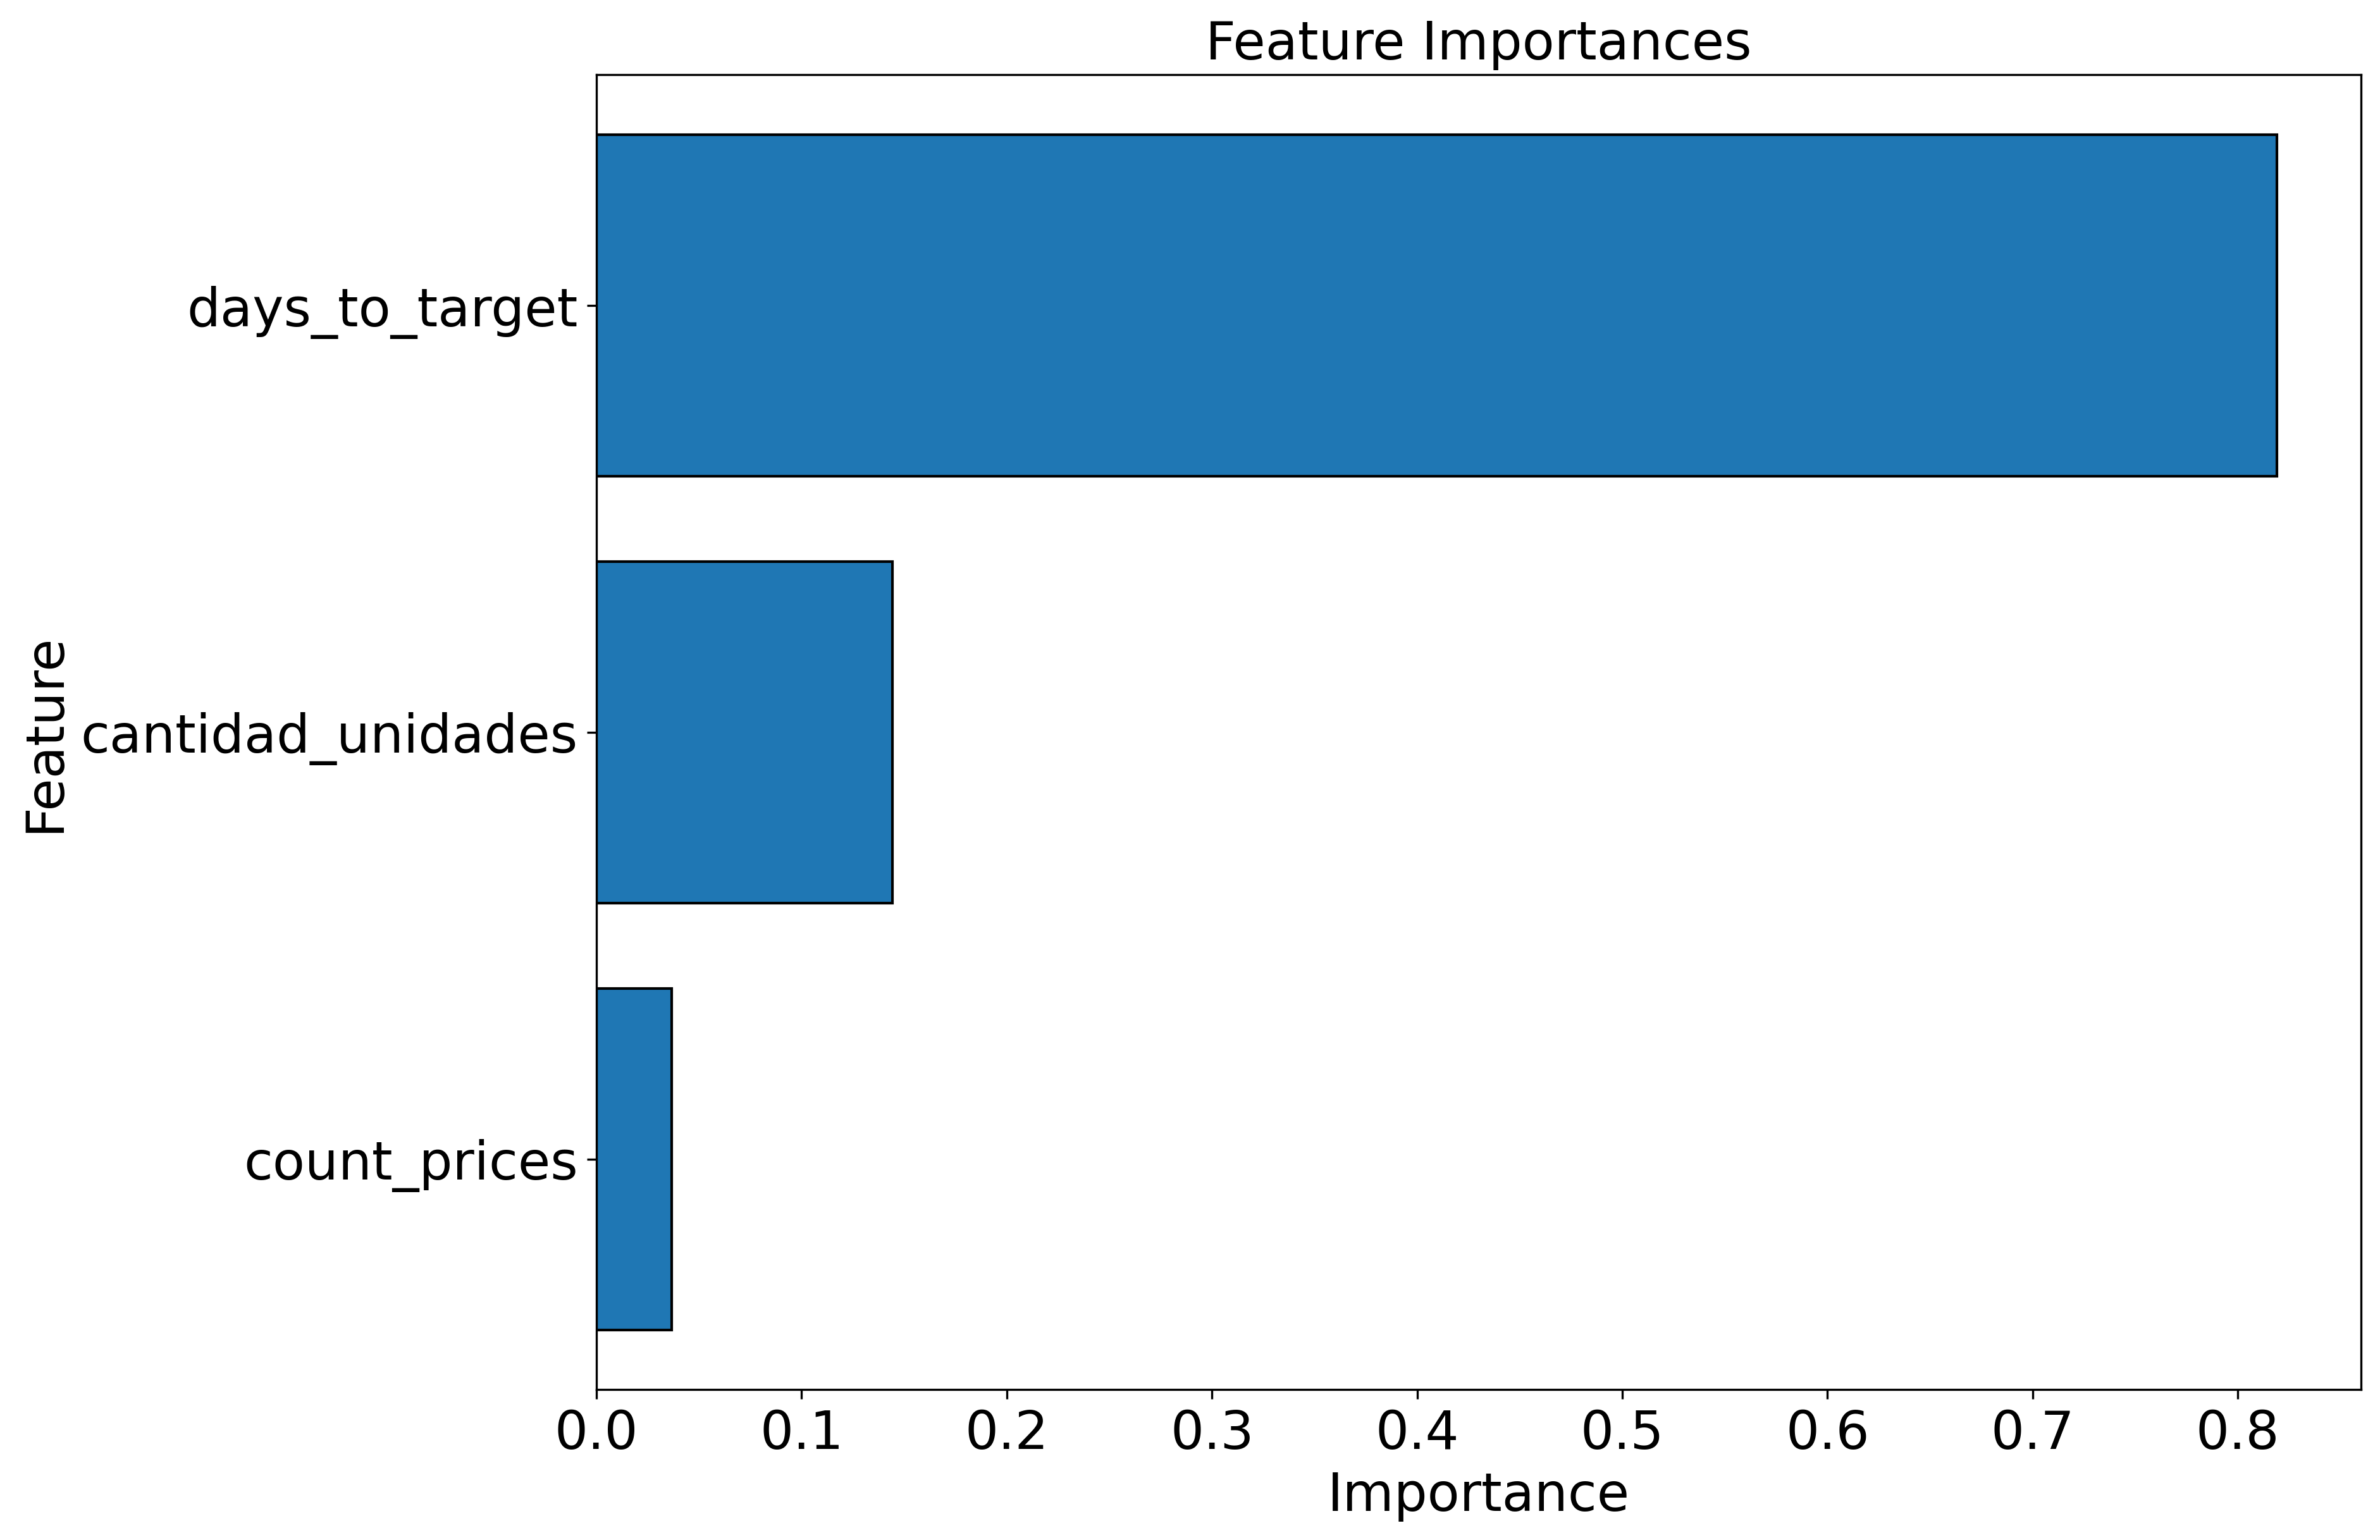

In [232]:
# Feature Importances
feature_importances = pd.DataFrame()
variable = []
score = []
for i,j in zip(X_train.columns, rnd_clf_v2.feature_importances_):
    variable.append(i)
    score.append(j)
feature_importances["variable"] = variable
feature_importances["score"] = score
feature_importances = feature_importances.sort_values(by = "score", ascending = False)
top_features = feature_importances.head(10).sort_values(by = "score", ascending = True)

fig, ax = plt.subplots(figsize = (12,9), dpi = 300)

ax.set_title("Feature Importances", fontsize = 20)
ax.barh(top_features["variable"], top_features["score"], edgecolor = 'black');

ax.set_xlabel("Importance", fontsize = 20)
ax.set_ylabel("Feature", fontsize = 20)
ax.tick_params(axis = 'both', which = 'major', labelsize = 20)

plt.savefig("feature_importances.png", bbox_inches = "tight")

# #feature_importances.to_csv("feature_importance_sinNunidades.csv", index= False)

 # Save Model
with open('aa_EarlyChurnPropertyModel_trainModel_rnd_clf_v5_10-04-2026_3_variables_importantes.pkl', 'wb') as f:
       pickle.dump(rnd_clf_v2, f)
print("Modelo guardado..")

plt.plot()





In [233]:
feature_importances

,variable,score
0,days_to_target,0.819101
2,cantidad_unidades,0.144172
1,count_prices,0.036728


In [234]:
###############
# Shap Values #
###############

print("Inicio de calculo de Shap Values...")

#Crear el objeto explicador SHAP (usa el modelo ya entrenado)
explainer = sp.TreeExplainer(rnd_clf_v2)

# Calcular los SHAP values sobre el set de test
shap_values = explainer.shap_values(X_test)

# Detectar estructura de salida
print(f"SHAP values shape: {np.array(shap_values).shape}")

# Si shap_values tiene 3 dimensiones, tomamos la clase positiva (último eje)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_array = shap_values[:, :, 1]  # eje final = clase 1
elif isinstance(shap_values, list):
    shap_array = shap_values[1]  # lista típica [clase0, clase1]
else:
    shap_array = shap_values  # array 2D normal

print(f"Usando SHAP array con shape: {shap_array.shape}")

# Crear DataFrame con importancia promedio por variable
shap_importance = pd.DataFrame({
    "variable": X_test.columns,
    "mean_abs_shap_value": np.abs(shap_array).mean(axis=0)
}).sort_values(by="mean_abs_shap_value", ascending=False).reset_index(drop=True)
print("\nCálculo de SHAP Values finalizado correctamente.")

# Mostrar en terminal las 15 más importantes
print("\nTop 15 variables más importantes según SHAP:")
print(shap_importance.head(26))

# Guardar todas las variables en un CSV
#shap_importance.to_csv("shap_importance_por_variable.csv", index=False, encoding="utf-8-sig")
#print("Generado archivo shap_importance_por_variable.csv (promedio por variable)")

# Gráfico 1: Importancia promedio de cada variable (barplot)
sp.summary_plot(shap_array, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Clase 1)")
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300)
plt.close()
print("Generado shap_feature_importance.png (importancia promedio)")

# Gráfico 2: Impacto de cada variable en la predicción (beeswarm)
sp.summary_plot(shap_array, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=300)
plt.close()
print("Generado shap_summary_beeswarm.png (impacto por variable)")

Inicio de calculo de Shap Values...
SHAP values shape: (39678, 3, 2)
Usando SHAP array con shape: (39678, 3)

Cálculo de SHAP Values finalizado correctamente.

Top 15 variables más importantes según SHAP:
            variable  mean_abs_shap_value
0     days_to_target             0.377255
1  cantidad_unidades             0.097142
2       count_prices             0.037980
Generado shap_feature_importance.png (importancia promedio)
Generado shap_summary_beeswarm.png (impacto por variable)


In [235]:
###############
# Shap Values #
###############

print("Inicio de calculo de Shap Values...")

#Crear el objeto explicador SHAP (usa el modelo ya entrenado)
explainer = sp.TreeExplainer(rnd_clf_v2)

# Calcular los SHAP values sobre el set de test
shap_values = explainer.shap_values(X_test)

# Detectar estructura de salida
print(f"SHAP values shape: {np.array(shap_values).shape}")

# Si shap_values tiene 3 dimensiones, tomamos la clase positiva (último eje)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_array = shap_values[:, :, 1]  # eje final = clase 1
elif isinstance(shap_values, list):
    shap_array = shap_values[1]  # lista típica [clase0, clase1]
else:
    shap_array = shap_values  # array 2D normal

print(f"Usando SHAP array con shape: {shap_array.shape}")

# Crear DataFrame con importancia promedio por variable
shap_importance = pd.DataFrame({
    "variable": X_test.columns,
    "mean_shap_value": shap_array.mean(axis=0)
}).sort_values(by="mean_shap_value", ascending=False).reset_index(drop=True)
print("\nCálculo de SHAP Values finalizado correctamente.")

# Mostrar en terminal las 15 más importantes
print("\nTop 15 variables más importantes según SHAP:")
print(shap_importance.head(26))

# Guardar todas las variables en un CSV
#shap_importance.to_csv("shap_importance_por_variable.csv", index=False, encoding="utf-8-sig")
#print("Generado archivo shap_importance_por_variable.csv (promedio por variable)")

# Gráfico 1: Importancia promedio de cada variable (barplot)
sp.summary_plot(shap_array, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Clase 1)")
plt.tight_layout()
plt.savefig("shap_feature_importance.png", dpi=300)
plt.close()
print("Generado shap_feature_importance.png (importancia promedio)")

# Gráfico 2: Impacto de cada variable en la predicción (beeswarm)
sp.summary_plot(shap_array, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary_beeswarm.png", dpi=300)
plt.close()
print("Generado shap_summary_beeswarm.png (impacto por variable)")

Inicio de calculo de Shap Values...
SHAP values shape: (39678, 3, 2)
Usando SHAP array con shape: (39678, 3)

Cálculo de SHAP Values finalizado correctamente.

Top 15 variables más importantes según SHAP:
            variable  mean_shap_value
0     days_to_target         0.009480
1       count_prices         0.006193
2  cantidad_unidades        -0.014422
Generado shap_feature_importance.png (importancia promedio)
Generado shap_summary_beeswarm.png (impacto por variable)
